In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import xgcm
import matplotlib.pyplot as plt
import xbudget

from load_example_ecco_grid import * 
from eccov4r4_budget_diagnostics import * 
from xbudget.llc90 import * 
print("xarray:",  xr.__version__)
print("xgcm:", xgcm.__version__)

xarray: 2026.4.0
xgcm: 0.9.0


In [4]:
transport_ds_path = "../../example-ECCOV4r4-budget-terms/data/ECCO_transport_terms.zarr"
ds = xr.open_mfdataset(transport_ds_path, parallel = True, engine = "zarr")
grid = construct_grid(ds)
grid

<xgcm.Grid>
Z Axis (not periodic, boundary='fill'):
  * center   k --> left
  * left     k_l --> center
  * outer    k_p1 --> center
  * right    k_u --> center
X Axis (not periodic, boundary='fill'):
  * center   i --> left
  * left     i_g --> center
Y Axis (not periodic, boundary='fill'):
  * center   j --> left
  * left     j_g --> center
T Axis (not periodic, boundary='fill'):
  * center   time

In [5]:
get_u_trsp = lambda u_ds: (u_ds*u_ds['drF']*u_ds['dyG']).where(u_ds["maskW"]).fillna(0)
get_v_trsp = lambda v_ds: (v_ds*v_ds['drF']*v_ds['dxG']).where(v_ds["maskS"]).fillna(0)
get_w_trsp = lambda w_ds: (w_ds * w_ds['rA']).fillna(0)

In [27]:
ds["UVELSTAR"].max()

<xarray.DataArray 'UVELSTAR' ()> Size: 4B
dask.array<_nanmax_skip-aggregate, shape=(), dtype=float32, chunksize=(), chunktype=numpy.ndarray>
Attributes:
    long_name:              Gent-McWilliams velocity in the model +x directio...
    units:                  m s-1
    mate:                   VVELSTAR
    coverage_content_type:  modelResult
    standard_name:          sea_water_x_velocity_due_to_parameterized_mesosca...
    comment:                Gent-McWilliams horizontal velocity in the +x dir...
    valid_min:              -0.4803895354270935
    valid_max:              0.3959691524505615

In [6]:
WBOL_TRSP = get_w_trsp(ds["WVELSTAR"])
UBOL_TRSP = get_u_trsp(ds["UVELSTAR"])
VBOL_TRSP = get_v_trsp(ds["VVELSTAR"])

U_TRSP = get_u_trsp(ds["UVELMASS"])
V_TRSP = get_v_trsp(ds["VVELMASS"])
W_TRSP = get_w_trsp(ds["WVELMASS"])

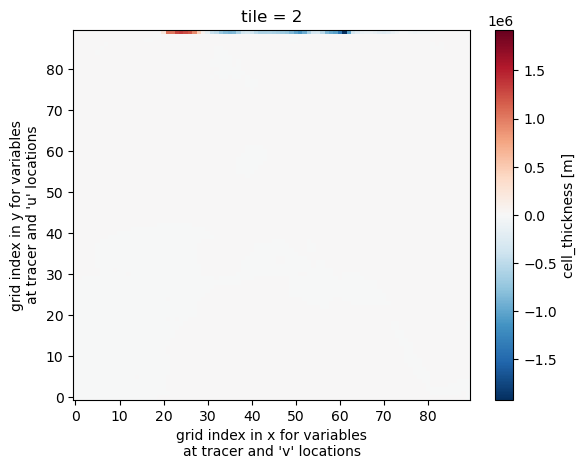

In [24]:
UBOL_vint = U_TRSP.sum(dim='k').mean("time")
VBOL_vint = V_TRSP.sum(dim='k').mean("time")

# difference in the x and y directions
diff_UBOL = grid.diff(UBOL_vint.chunk({"tile":-1, "i_g":-1, "j":-1}), "X")
diff_VBOL = grid.diff(VBOL_vint.chunk({"tile":-1, "i":-1, "j_g":-1}), "Y")
(diff_UBOL + diff_VBOL).isel(tile = 2).plot()

/Users/anthonymeza/Library/CloudStorage/OneDrive-MassachusettsInstituteofTechnology/Documents/GitHub/xbudget/xbudget/llc90/operations.py:63: UserWarning: Dataset chunks are inconsistent; using unify_chunks()
  warnings.warn("Dataset chunks are inconsistent; using unify_chunks()", UserWarning)
/Users/anthonymeza/miniforge3/envs/docs_env_xbudget/lib/python3.12/site-packages/xarray/structure/chunks.py:183: PerformanceWarning: Increasing number of chunks by factor of 20
  _, chunked_data = chunkmanager.unify_chunks(*unify_chunks_args)


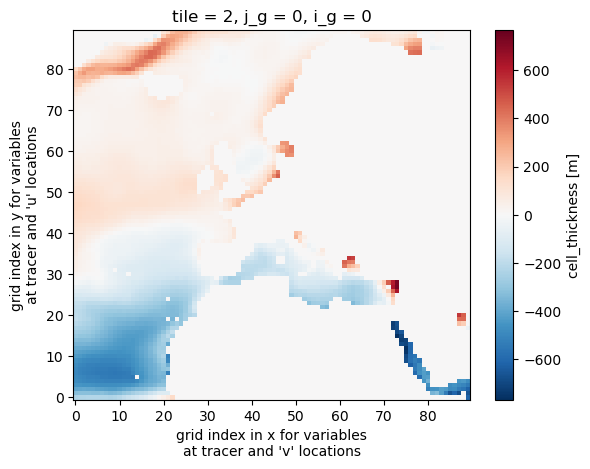

In [25]:
diff_UV_BOL = diff_2d_flux_llc90(grid, UBOL_vint, VBOL_vint, allow_rechunk = True)
diff_UBOL = diff_UV_BOL["X"]
diff_VBOL = diff_UV_BOL["Y"]
(diff_UBOL + diff_VBOL).isel(tile = 2).plot()

In [ ]:
grid = load_ECCOV4r4_coarsened_diagnostics() # this takes about 7 minutes

# Build a time-step coordinate and a cell-volume metric used repeatedly below.
dt = grid._ds["time_bounds"].diff("time_bounds").rename({"time_bounds":"time"})

grid._ds = grid._ds.assign_coords(
    {"dt":("time", dt.dt.total_seconds().values), 
    "volcello": (grid._ds["drF"] * grid._ds["hFacC"]) * grid._ds["rA"]
    }
)

### Preprocess standard ECCO diagnostics 
The ECCO V4r4 fields hosted on PO.DAAC contain the ingredients needed to close native-grid mass, heat, and salt budgets, but a few terms need to be reorganized before they match the bookkeeping expected by `xbudget`. In particular, some diagnostics combine interior and boundary contributions, while others separate penetrative and non-penetrative surface forcing.

In [ ]:
def zero_top_layer(ds, varname = "", zdim = "k_l"):
    # Remove the surface layer contribution when a diagnostic should only represent interior transport.
    return xr.where(ds[f"{zdim}"] != ds[f"{zdim}"].isel({f"{zdim}":0}),ds[varname].copy(),0.0,)
def make_flux_3d(ds, varname = "", zdim = "k"):
    # Broadcast a surface flux into a 3D array that only occupies the top model layer.
    k  = ds[f"{zdim}"]
    return xr.where(k == k.isel({f"{zdim}":0}), ds[varname].copy().expand_dims({f"{zdim}":k}),0.0,)

# Assemble ECCO heat-flux terms into the budget components expected by xbudget.
grid._ds["geothermal_heat_flux_convergence"] = eccov4r4_geothermal_heat_flux_tendency(grid._ds) 
grid._ds["pen_boundary_forcing_heat_tendency"] = eccov4r4_penetrative_heat_flux_tendency(grid._ds)
grid._ds["nonpen_boundary_forcing_heat_tendency"] = eccov4r4_nonpenetrative_heat_flux_tendency(grid._ds)
grid._ds["boundary_forcing_heat_tendency"] = grid._ds["pen_boundary_forcing_heat_tendency"] + grid._ds["nonpen_boundary_forcing_heat_tendency"]

# Put the sea-ice salt exchange and salt-plume tendency onto the same vertical grid.
SFLUX = grid._ds["SFLUX"].assign_coords(k=0).expand_dims(dim='k',axis=1) # sea-ice salt exchange
grid._ds["boundary_forcing_salt_tendency"] = xr.concat([SFLUX+grid._ds["oceSPtnd"],grid._ds["oceSPtnd"].isel(k=slice(1,None))], dim='k') # combine surface salt flux and plume tendency

# Separate interior vertical transport from the freshwater boundary forcing term.
grid._ds["WVELMASS_interior"] = zero_top_layer(grid._ds, varname = "WVELMASS", zdim = "k_l") #
grid._ds["boundary_forcing_volume_tendency"] = make_flux_3d(grid._ds, varname = "oceFWflx", zdim = "k")

# Rechunk once before calling xbudget so later difference and convergence steps stay tractable.
grid._ds = grid._ds.chunk({"tile":2, "i":50, "j":50, "i_g":50, "j_g":50, "k": 10}).fillna(0.0)
# to-do: add comparable chunking inside the difference and convergence routines 

### Load budget metadata from the ECCO preset dictionary
This preset tells `xbudget` which variables belong on the left-hand side, which belong on the right-hand side, and how derived budget terms should be combined.

In [ ]:
# Load the preset metadata dictionary and let xbudget attach the derived budget terms.
xbudget_dict = xbudget.load_preset_budget(model="ECCOV4r4_native").copy()
xbudget.collect_budgets(grid, xbudget_dict,allow_rechunk= True)
# Aggregate the full metadata tree into a simpler budget summary for inspection.
simple_budgets = xbudget.aggregate(xbudget_dict)
simple_budgets

### Verify that the budgets close

The checks below compare the left-hand-side (LHS) storage tendency against the diagnosed sum of the right-hand-side (RHS) source, sink, and flux-convergence terms. We look at both spatial patterns and globally averaged time series. Because ECCO uses the LLC grid, the maps are first remapped to a regular latitude-longitude grid for quick visualization.

Refer to `MOM6_budget_examples_mass_heat_salt.ipynb` for a more detailed explanation of the `xbudget` workflow.

In [ ]:
def plot_interpolated_ecco(fig, ax, ds, vmin=0, vmax=30, cmap="coolwarm"):
    # Build a simple regular lat-lon target grid for quick visual comparison.
    target_lon = np.arange(-180, 180, 1)
    target_lat = np.arange(-90, 90, 1)
    lon_grid, lat_grid = np.meshgrid(target_lon, target_lat)
    
    # Flatten the LLC field into point/value pairs for interpolation.
    points = np.column_stack((ds.XC.values.ravel(), ds.YC.values.ravel()))
    values = ds.values.ravel()
    
    # Use nearest-neighbor remapping to preserve the native diagnostic values.
    interpolated_data = griddata(points, values, (lon_grid, lat_grid), method='nearest')
    
    # Plot the remapped field.
    cb = ax.pcolormesh(lon_grid, lat_grid, interpolated_data, 
                       vmin=vmin, vmax=vmax, cmap=cmap)
    
    return cb

### Volume budgets
This first check verifies that the vertically integrated volume tendency is balanced by the diagnosed transport and boundary-forcing terms.

In [ ]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

# Restrict horizontal area to wet points before forming column integrals.
area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

# Convert native volume-integrated tendencies into column tendencies per unit area.
lhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "mass_lhs")["var"]] / area).sum("k") # convert from kg/s to kg / s/ m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "mass_rhs_sum")["var"]] / area).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

# Residual should be small if the budget closes.
tendency_difference = lhs_tendency - rhs_tendency

vmax = 5e-4
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax0.set_title("Column mass tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax1.set_title("Column mass tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "kg / s/ m^2")

# Area-weighted global means summarize the closure error over time.
((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global mass tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global mass tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("kg / s/ m^2")
ax_bottom.legend()

### Heat budgets
This check compares the column-integrated heat tendency against the assembled surface and transport contributions.

In [ ]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

# Restrict horizontal area to wet points before forming column integrals.
area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

# Convert native volume-integrated heat tendencies into column tendencies per unit area.
lhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "heat_lhs")['var']] / area).sum("k") # convert from J/s to W/m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "heat_rhs")['var']] / area).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

# Residual should be small if the budget closes.
tendency_difference = lhs_tendency - rhs_tendency

vmax = 1000
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax0.set_title("Column heat tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax1.set_title("Column heat tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "W/ m^2")

# Area-weighted global means summarize the closure error over time.
((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global heat tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global heat tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("W/ m^2")
ax_bottom.legend()

### Salt budgets
This final check compares the column-integrated salt tendency against the diagnosed salt sources, sinks, and transport terms.

In [ ]:
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1,  0.06], height_ratios=[1, 0.5], hspace=0.25, wspace=0.15)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0); ax1.tick_params(labelleft=False)
ax2 = fig.add_subplot(gs[0, 2], sharey=ax0); ax2.tick_params(labelleft=False)
cax = fig.add_subplot(gs[0, 3])
ax_bottom = fig.add_subplot(gs[1, :])

# Restrict horizontal area to wet points before forming column integrals.
area = grid._ds["rA"].where(grid._ds["Depth"] > 0.0)

# Convert native volume-integrated salt tendencies into column tendencies per unit area.
lhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "salt_lhs")['var']] / area).sum("k") # convert from kg/s to kg/s/m^2
lhs_tendency = lhs_tendency.where(np.abs(lhs_tendency) > 0.0)

rhs_tendency = (grid._ds[xbudget.get_vars(xbudget_dict, "salt_rhs")['var']] / area).sum("k")
rhs_tendency = rhs_tendency.where(np.abs(rhs_tendency) > 0.0)

# Residual should be small if the budget closes.
tendency_difference = lhs_tendency - rhs_tendency

vmax = 1e-5
plot_interpolated_ecco(fig, ax0, lhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax0.set_title("Column salt tendency\n(LHS)")
plot_interpolated_ecco(fig, ax1, rhs_tendency.isel(time=0), vmin=-vmax, vmax=vmax); ax1.set_title("Column salt tendency\n(RHS, diagnosed)")
cb = plot_interpolated_ecco(fig, ax2, tendency_difference.isel(time=0), vmin=-vmax, vmax=vmax); ax2.set_title("LHS minus RHS")
fig.colorbar(cb, cax=cax, orientation="vertical", label = "kg/s/m^2")

# Area-weighted global means summarize the closure error over time.
((lhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "o", label = "Global salt tendency\n(LHS)")
((rhs_tendency * area) / area.sum()).sum(["tile", "i", "j"]).plot(ax = ax_bottom, marker = "*", label = "Global salt tendency\n(RHS, diagnosed)")
ax_bottom.set_ylabel("kg/s/m^2")
ax_bottom.legend()